# Imports

In [1]:
import os
import sys
import torch

from utils.checkpoint import load_checkpoint, save_checkpoint
from utils.data import get_dataloaders

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config


In [18]:
config = Config()
device = config.device

# Prepare data
_, val_loader, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
lenet_model = LeNet(
    prior_sigma1=config.prior_sigma1,
    prior_sigma2=config.prior_sigma2,
    prior_pi=config.prior_pi,
    num_classes=config.num_classes,
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(lenet_model.parameters(), lr=config.learning_rate)
# Load weights
# config.model_name = 'mnist_bayesian_lenet'
load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.get_checkpoint_name(130, date="20260122")}', device)
# load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.get_checkpoint_name(475, date="20251201")}', device)


[checkpoint] Loaded from ../checkpoints/lenet_mnist_lrp1em05_prior11_prior20_priorpi1_epoch_130_20260122.pth, starting at epoch 131


131

# Evaluate

In [35]:
from utils.calibration import reliability_diagram
reliability_diagram(lenet_model, test_loader, device, T=5)

TypeError: '>' not supported between instances of 'list' and 'Tensor'

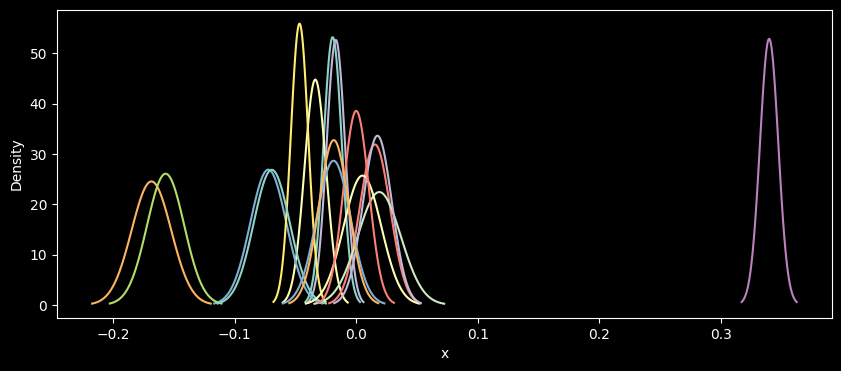

In [20]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

mu = lenet_model.fc1.mu.detach().cpu().flatten().numpy()
sigma = torch.log1p(torch.exp(lenet_model.fc1.rho)).detach().cpu().flatten().numpy()

num_weights = 16 # * 5 * 5 # * 120
fig, ax = plt.subplots(figsize=(10, 4), sharey=True)
plt.ylabel('Density')
plt.xlabel('x')
for w_idx in range(num_weights):
    # Плотность q(w|θ) для одного веса
    w_range = np.linspace(mu[w_idx] - 3*sigma[w_idx], mu[w_idx] + 3*sigma[w_idx], 100)
    density = norm.pdf(w_range, mu[w_idx], sigma[w_idx])

    plt.plot(w_range, density)


In [34]:
from evaluate import evaluate_with_uncertainty

evaluate_with_uncertainty(lenet_model, test_loader, device, mc_samples=20)

Total Uncertainty (mean): 0.049695078283548355
Aleatoric (mean): 0.03069913014769554
Epistemic (mean): 0.018995942547917366


(tensor([7, 2, 1,  ..., 4, 5, 6]),
 (tensor([0.0018, 0.0898, 0.0007,  ..., 0.0013, 0.0124, 0.0036]),
  tensor([0.0018, 0.0589, 0.0007,  ..., 0.0013, 0.0122, 0.0035]),
  tensor([1.3429e-06, 3.0831e-02, 1.0069e-06,  ..., 5.0308e-07, 2.8578e-04,
          1.6179e-05])))

# Images

In [3]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    """
    Add salt and pepper noise to an image
    Args:
        image: torch tensor of shape (1, 28, 28) for MNIST
        salt_prob: probability of salt noise (white pixels)
        pepper_prob: probability of pepper noise (black pixels)
    """
    noisy_image = image.clone()

    # Create random mask for salt noise
    salt_mask = torch.rand_like(image) < salt_prob
    # Create random mask for pepper noise
    pepper_mask = torch.rand_like(image) < pepper_prob

    # Apply salt noise (set to 1)
    noisy_image[salt_mask] = 1.0
    # Apply pepper noise (set to 0)
    noisy_image[pepper_mask] = 0.0

    return noisy_image

def add_salt_pepper_noise_normalized(image, salt_prob=0.05, pepper_prob=0.05, data_mean=0.1307, data_std=0.3081):
    """
    Add salt and pepper noise to a NORMALIZED MNIST image
    """
    noisy_image = image.clone()

    # Calculate normalized values for min (0) and max (1)
    normalized_min = (0.0 - data_mean) / data_std  # ≈ -0.424
    normalized_max = (1.0 - data_mean) / data_std  # ≈ 2.823

    # Create random masks
    salt_mask = torch.rand_like(image) < salt_prob
    pepper_mask = torch.rand_like(image) < pepper_prob

    # Apply salt noise (set to normalized max)
    noisy_image[salt_mask] = normalized_max
    # Apply pepper noise (set to normalized min)
    noisy_image[pepper_mask] = normalized_min

    return noisy_image

In [4]:
from matplotlib import pyplot as plt
from itertools import islice, accumulate
from utils.uncertainty import quantify_uncertainties


def display_images_with_uncertainty(model, test_loader, batch_idx=0, img_idx=0, salt_prob=0.05, pepper_prob=0.05, T=5):
    # Get the i-th batch using islice
    data, target = next(islice(test_loader, batch_idx, batch_idx+1))
    data, target = data.to(device), target.to(device)
    output, uncertainties = quantify_uncertainties(model, data, T)

    # Get first image from batch
    img = data[img_idx]
    print(f"Original image shape: {img.shape}")

    # Add salt and pepper noise to the image
    noisy_img = add_salt_pepper_noise_normalized(img, salt_prob=salt_prob, pepper_prob=pepper_prob)

    # Create subplots to compare original and noisy images
    fig, ax = plt.subplots(figsize=(10, 4))

    # Plot original image
    ax.imshow(img.squeeze().cpu().numpy(), cmap='gray')
    ax.set_title(f'Original\nLabel: {target[img_idx].item()}')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Total uncertainty: {uncertainties[0].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")
    print(f"Aleatoric uncertainty: {uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")
    print(f"Epistemic uncertainty: {uncertainties[2].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")


Original image shape: torch.Size([1, 28, 28])


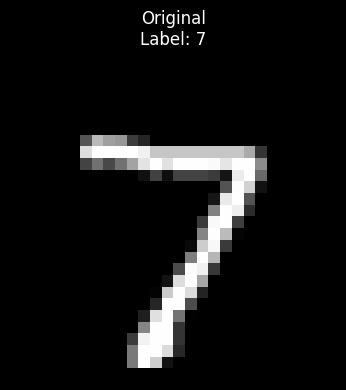

Total uncertainty: 0.0017080644611269236
Aleatoric uncertainty: 0.0017079857643693686
Epistemic uncertainty: 7.866679396784093e-08


In [7]:
# Цифра 3
display_images_with_uncertainty(lenet_model, test_loader, batch_idx=0, img_idx=0, salt_prob=0.1, pepper_prob=0.5, T=15)

# Corruptions

In [3]:
def add_salt_pepper(image, salt_prob=0.05, pepper_prob=0.05, data_mean=0.1307, data_std=0.3081):
    noisy_image = image.clone()

    # Calculate normalized values for min (0) and max (1)
    normalized_min = (0.0 - data_mean) / data_std  # ≈ -0.424
    normalized_max = (1.0 - data_mean) / data_std  # ≈ 2.823

    # Create random masks
    salt_mask = torch.rand_like(image) < salt_prob
    pepper_mask = torch.rand_like(image) < pepper_prob

    # Apply salt noise (set to normalized max)
    noisy_image[salt_mask] = normalized_max
    # Apply pepper noise (set to normalized min)
    noisy_image[pepper_mask] = normalized_min

    return noisy_image

def gaussian_blur(img, kernel_size):
    from torchvision.transforms.functional import gaussian_blur
    return gaussian_blur(img, kernel_size)

def rotate(img, angle):
    from torchvision.transforms.functional import rotate
    return rotate(img, angle)

In [4]:
corruptions = {
    'Original': lambda x: x,
    'Gaussian Noise': lambda x: x + torch.randn_like(x) * 0.3,
    'Salt & Pepper': lambda x: add_salt_pepper(x, 0.1),
    'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'Rotation': lambda x: rotate(x, 45),
}

In [39]:
import random
from itertools import islice
import matplotlib.pyplot as plt
from utils.uncertainty import quantify_uncertainties, mc_predict

def test_on_corruptions(model, test_loader, device, T=5, batch_idx=0, img_idx=0):
    """Проверка на разных типах искажений"""

    img, label = next(islice(test_loader, batch_idx, batch_idx+1))
    img = img.to(device)

    fig, axes = plt.subplots(5, len(corruptions.keys()), figsize=(15, 10))

    for col, (name, corrupt_fn) in enumerate(corruptions.items()):
        corrupted = corrupt_fn(img[img_idx]).unsqueeze(0)
        mc_preds = mc_predict(model, corrupted, mc_samples=T)
        logits_std = mc_preds.std(dim=0).mean()
        # print(f"Logits std: {logits_std:.4f}")
        pred, (total, alea, epis) = quantify_uncertainties(mc_preds)

        # диагональ = variance по каждому классу
        total_diag = total.diagonal(dim1=1, dim2=2)   # [B, C]
        alea_diag = alea.diagonal(dim1=1, dim2=2)   # [B, C]
        epis_diag = epis.diagonal(dim1=1, dim2=2)   # [B, C]

        # маска "не target"
        mask = torch.ones_like(total_diag, dtype=torch.bool)
        mask[0, pred[0]] = 0
        # mask[0, label[img_idx]] = 0

        total_label_unc = total[0, label[img_idx], label[img_idx]].item()
        alea_label_unc  = alea[0, label[img_idx], label[img_idx]].item()
        epis_label_unc  = epis[0, label[img_idx], label[img_idx]].item()
#         print(f"""
# {name} - Pred: {pred.item()}, Label: {label[img_idx].item()}
# Total uncertainty - Pred: {total[0, pred[0], pred[0]].item():.4f}, Label: {total_label_unc:.4f}
# Aleatoric uncertainty - Pred: {alea[0, pred[0], pred[0]].item():.4f}, Label: {alea_label_unc:.4f}
# Epistemic uncertainty - Pred: {epis[0, pred[0], pred[0]].item():.4f}, Label: {epis_label_unc:.4f}
#
# Total uncertainty (not pred): {total_diag[mask].view(-1, 9).sum(dim=1).item():.4f}
# Aleatoric uncertainty (not pred): {alea_diag[mask].view(-1, 9).sum(dim=1).item():.4f}
# Epistemic uncertainty (not pred): {epis_diag[mask].view(-1, 9).sum(dim=1).item():.4f}
# """)

        total_pred_unc = total[0, pred[0], pred[0]].item()
        alea_pred_unc  = alea[0, pred[0], pred[0]].item()
        epis_pred_unc  = epis[0, pred[0], pred[0]].item()

        total_not_pred_unc = total_diag[mask].view(-1, 9).sum(dim=1).item()
        alea_not_pred_unc  = alea_diag[mask].view(-1, 9).sum(dim=1).item()
        epis_not_pred_unc  = epis_diag[mask].view(-1, 9).sum(dim=1).item()

        # Изображение
        axes[0, col].imshow(corrupted.cpu().squeeze(), cmap='gray')
        axes[0, col].set_title(f'{name}\nPred: {pred.item()}')
        axes[0, col].axis('off')

        ax = axes[1, col]
        ax.bar(
            ['T', 'A', 'E'],
            [total_pred_unc, alea_pred_unc, epis_pred_unc],
            color=['#3498db', '#e74c3c', '#2ecc71'],
            alpha=0.8
        )
        ax.set_ylabel('Uncertainty')
        ax.set_ylim(bottom=0)

        ax = axes[2, col]
        ax.bar(
            ['T', 'A', 'E'],
            [total_not_pred_unc, alea_not_pred_unc, epis_not_pred_unc],
            color=['#3498db', '#e74c3c', '#2ecc71'],
            alpha=0.8
        )
        ax.set_ylabel('Uncertainty')
        ax.set_ylim(bottom=0)

        ax = axes[3, col]
        ax.bar(
            ['T', 'A', 'E'],
            [total_label_unc, alea_label_unc, epis_label_unc],
            color=['#3498db', '#e74c3c', '#2ecc71'],
            alpha=0.8
        )
        ax.set_ylabel('Uncertainty')
        ax.set_ylim(bottom=0)

        FIXED_MAX = 0.5  # или любое другое значение

        for row in range(1, 4):
            axes[row, col].set_ylim(0, FIXED_MAX)

        # MC-предсказания
        mean_probs = mc_preds.mean(dim=0)[0]
        axes[4, col].bar(range(10), mean_probs.cpu().numpy())
        axes[4, col].set_xlabel('Class')
        axes[4, col].set_ylabel('Probability')
        axes[4, col].set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

## Blur

In [24]:
corruptions = {
    'Original': lambda x: x,
    # 'Gaussian Noise': lambda x: x + torch.randn_like(x) * 0.3,
    # 'Salt & Pepper': lambda x: add_salt_pepper(x, 0.1),
    'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'Default Blur': lambda x: gaussian_blur(x, kernel_size=5),
    'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
    # 'Rotation': lambda x: rotate(x, 45),
}

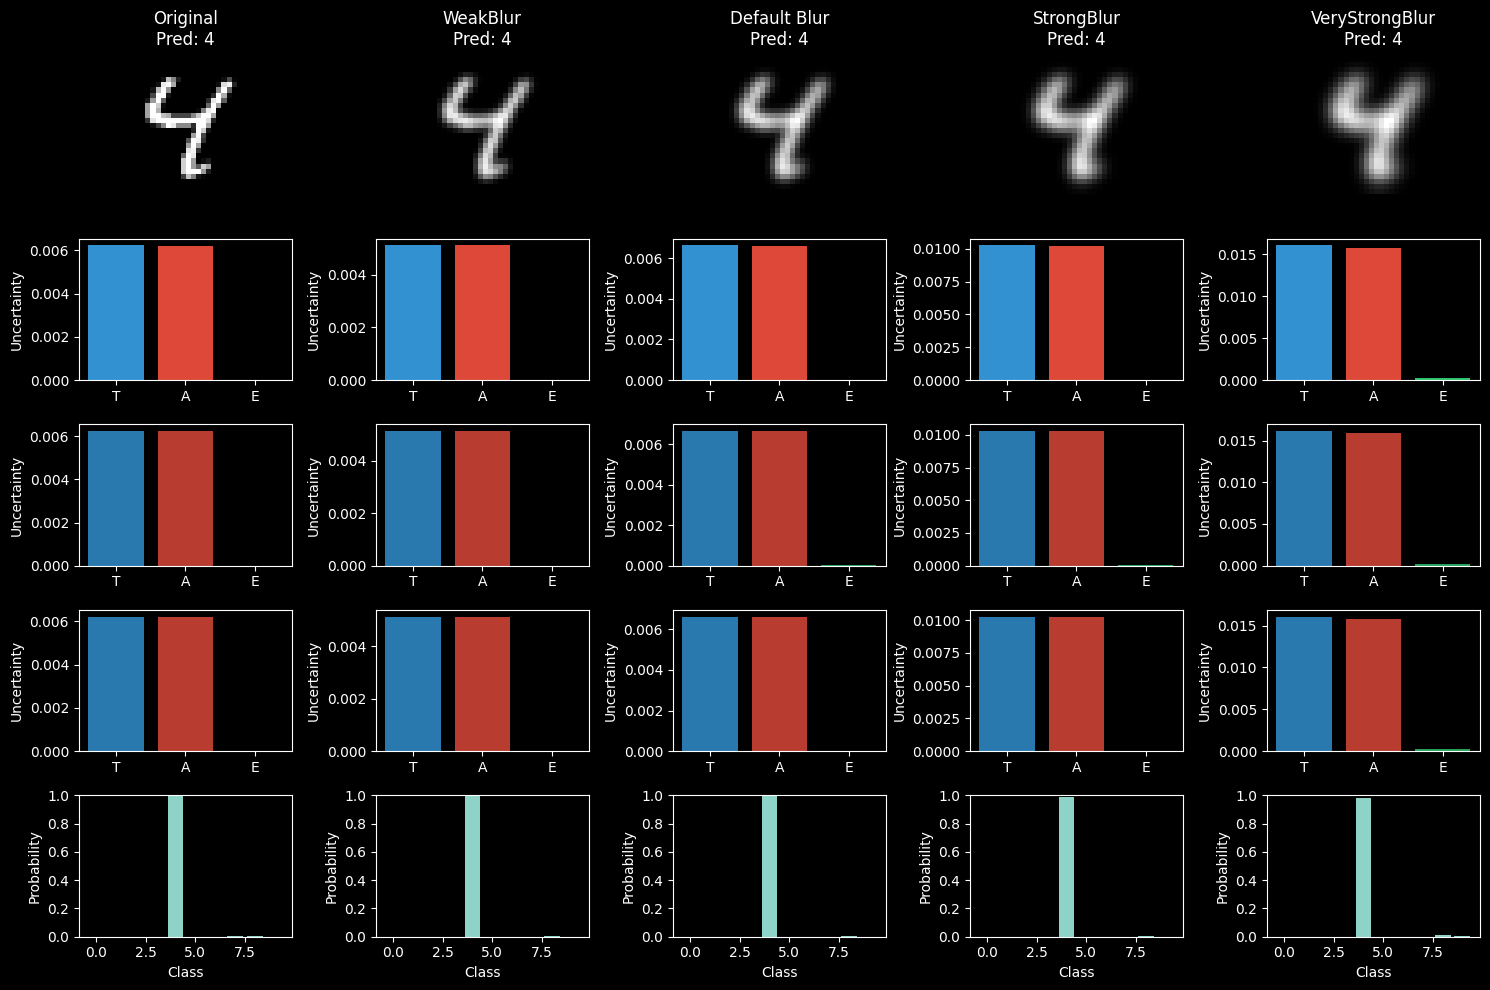

In [25]:
test_on_corruptions(lenet_model, test_loader, device, T=20, img_idx=6)

Random batch index: 569, image index: 2


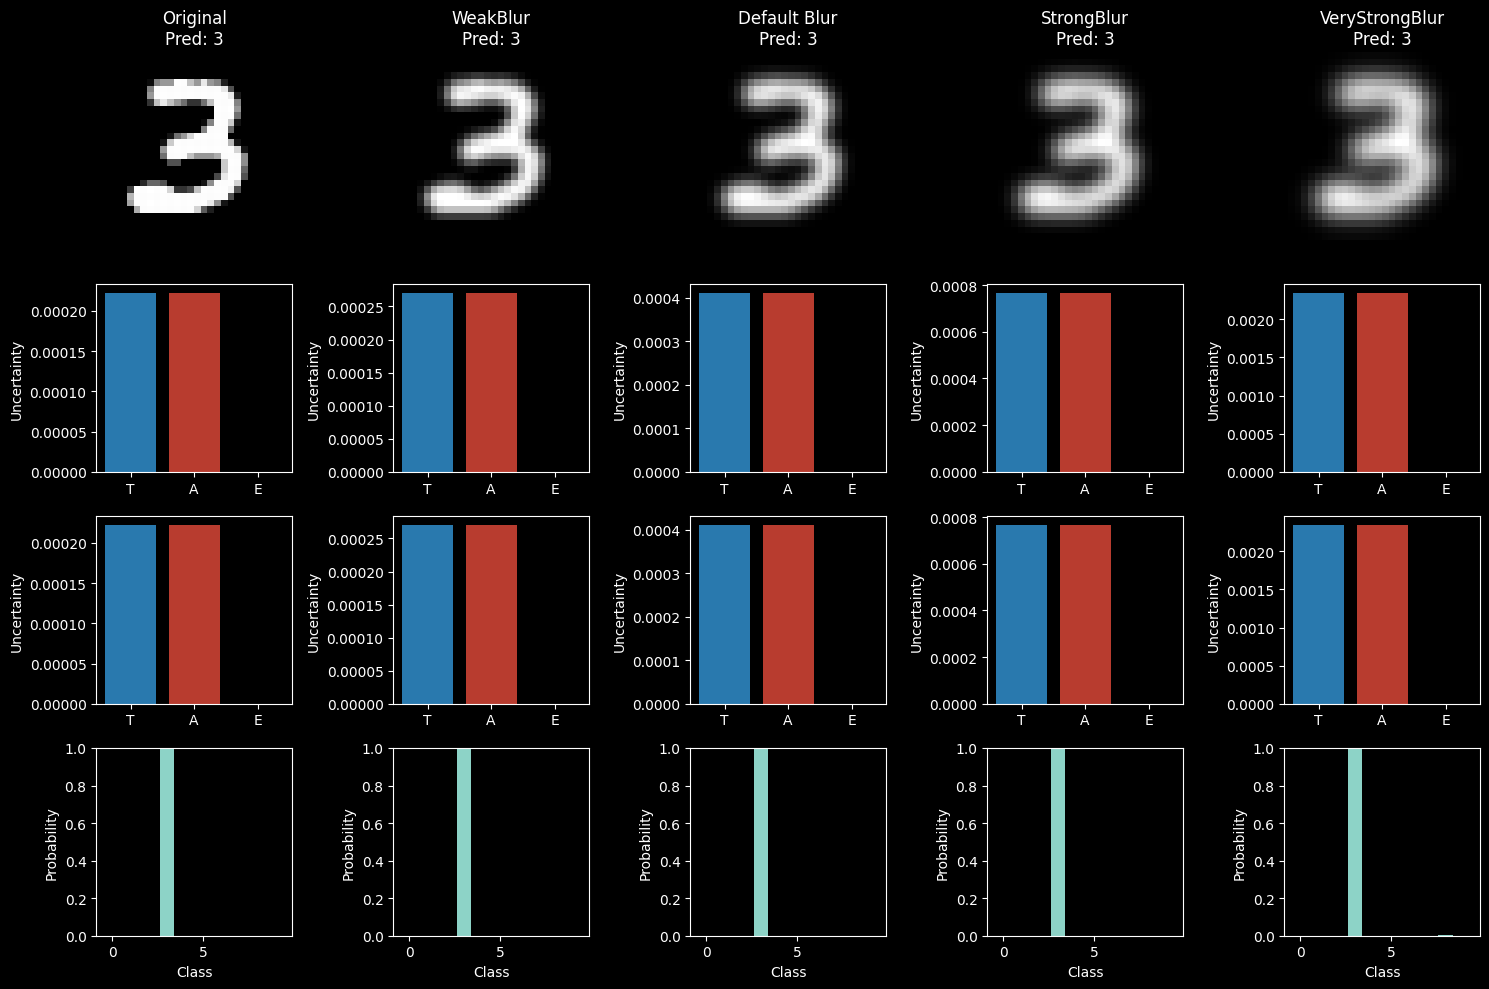

In [35]:
rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
test_on_corruptions(lenet_model, test_loader, device, batch_idx=rand_batch_idx, img_idx=rand_img_idx)

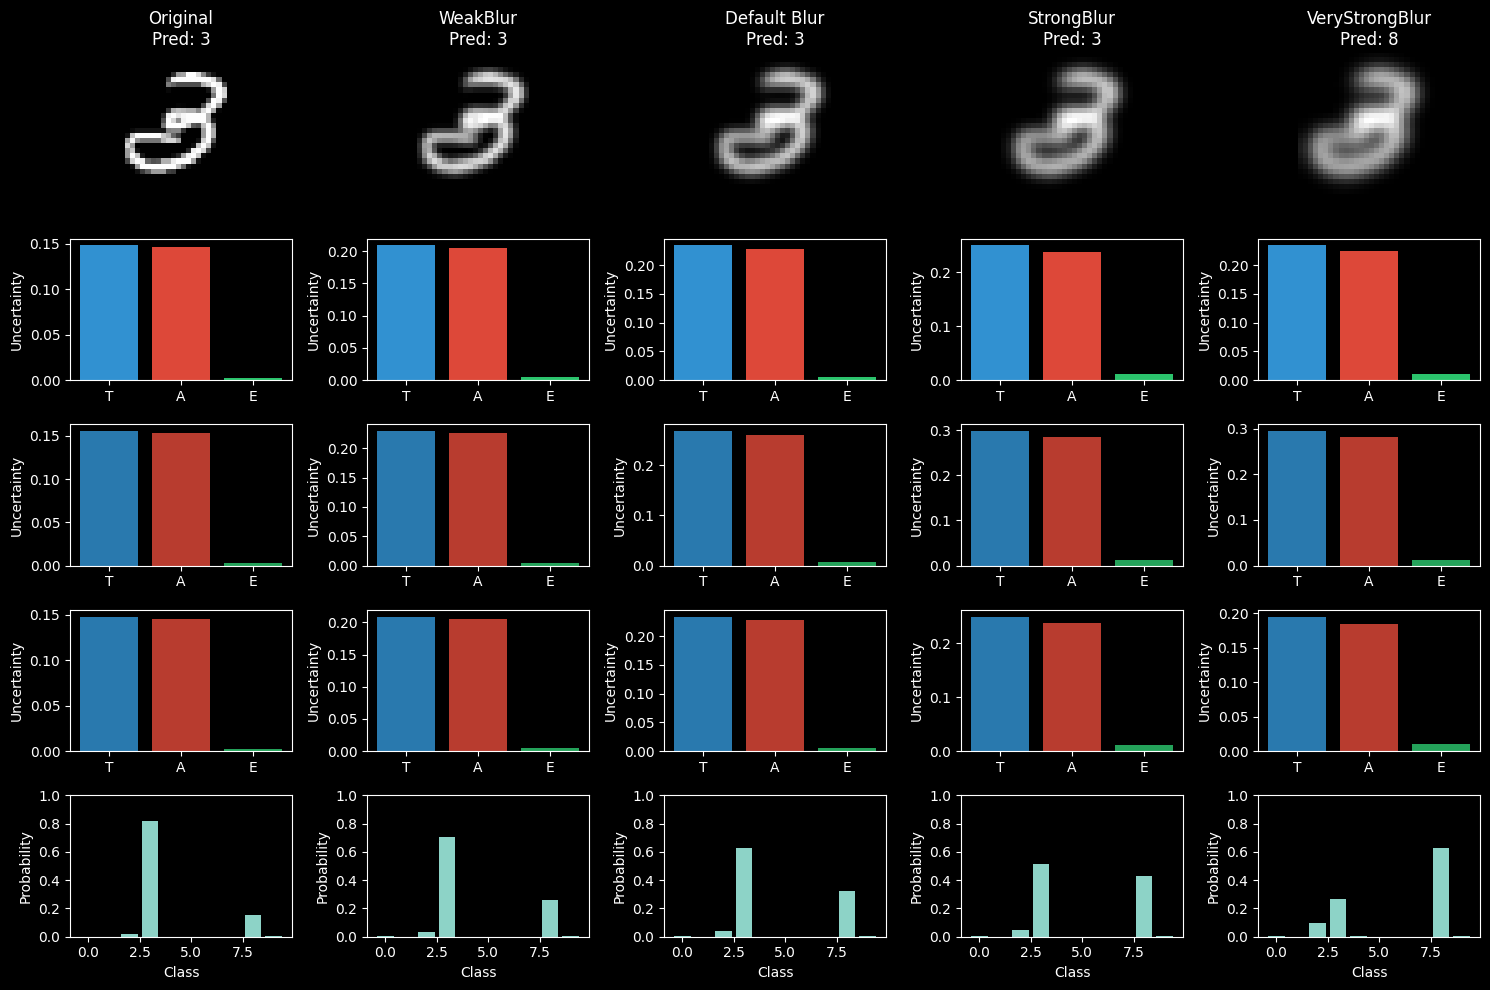

In [26]:
test_on_corruptions(lenet_model, test_loader, device, batch_idx=695, img_idx=12)

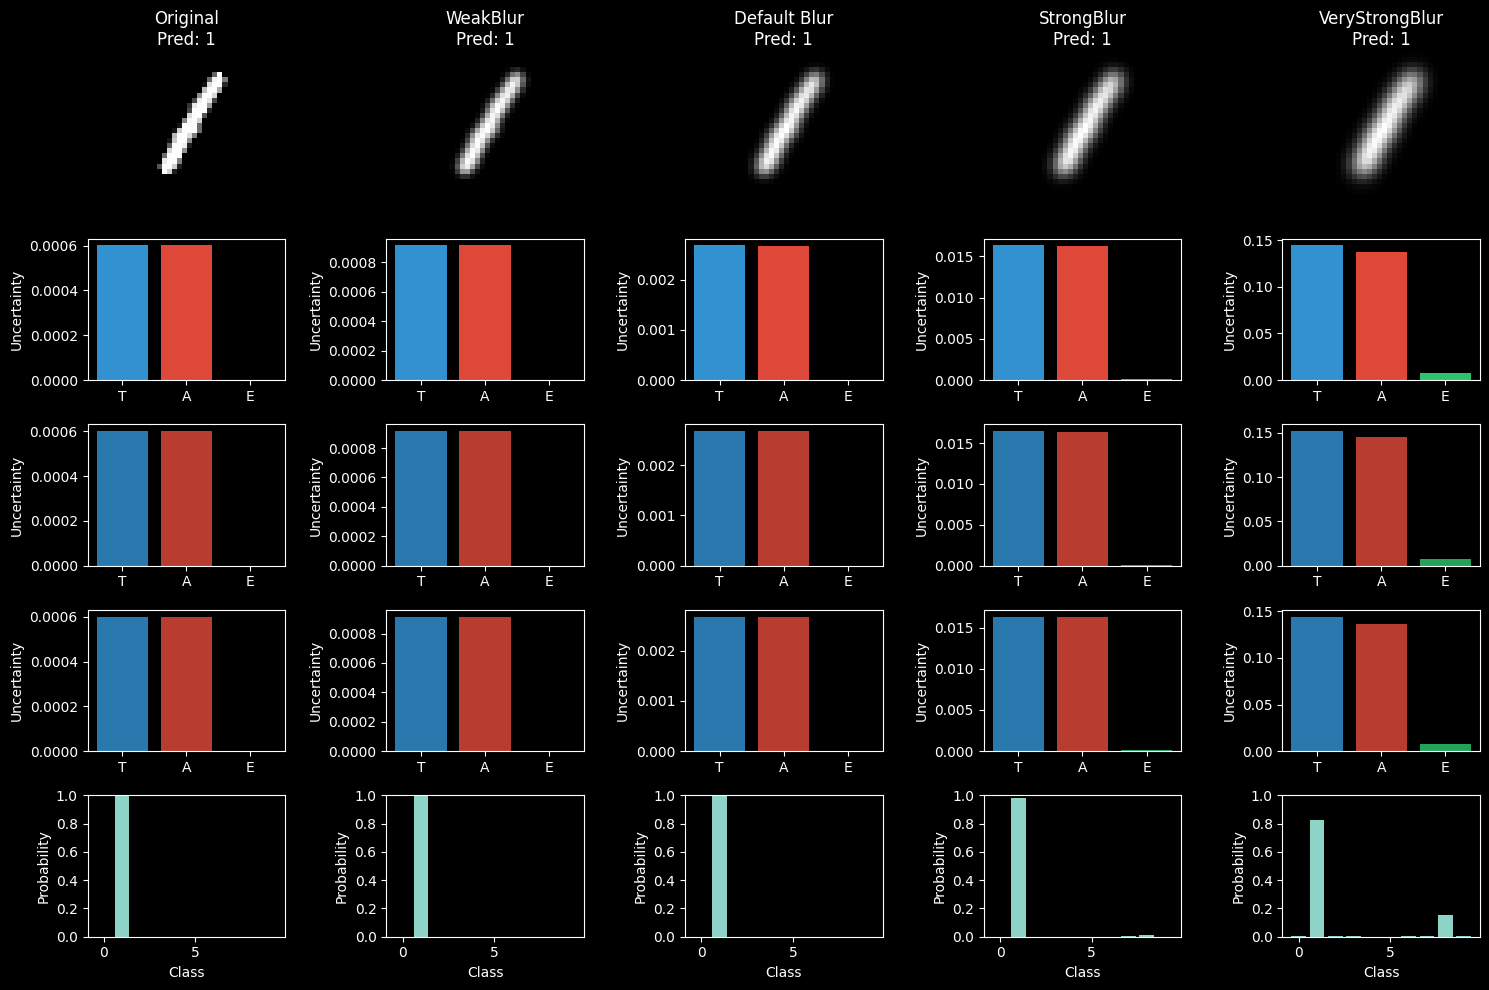

In [27]:
test_on_corruptions(lenet_model, test_loader, device, T=15, batch_idx=130, img_idx=0)

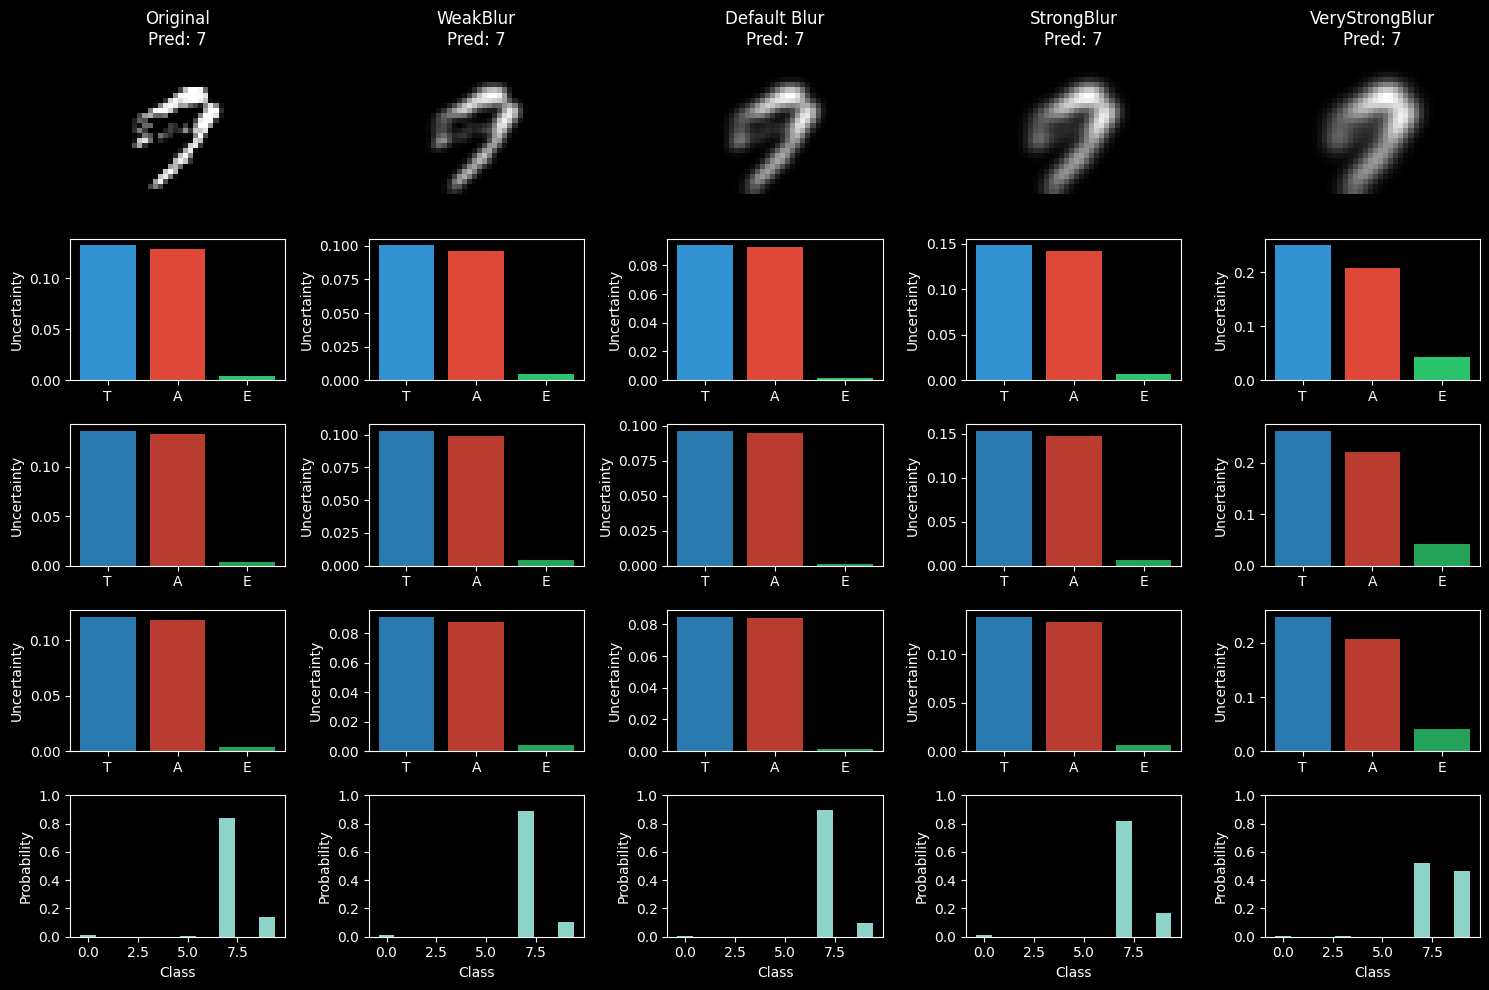

In [28]:
test_on_corruptions(lenet_model, test_loader, device, T=15, batch_idx=688, img_idx=10)

## Salt & Pepper

In [29]:
corruptions = {
    'Original': lambda x: x,
    'Weak Salt': lambda x: add_salt_pepper(x, 0.01, 0.01),
    'Default Salt': lambda x: add_salt_pepper(x, 0.03, 0.01),
    'Strong Salt': lambda x: add_salt_pepper(x, 0.05, 0.01),
    'Very Strong Salt': lambda x: add_salt_pepper(x, 0.07, 0.01),
    'Weak Pepper': lambda x: add_salt_pepper(x, 0.01, 0.01),
    'Default Pepper': lambda x: add_salt_pepper(x, 0.01, 0.07),
    'Strong Pepper': lambda x: add_salt_pepper(x, 0.01, 0.12),
    'Very Strong Pepper': lambda x: add_salt_pepper(x, 0.01, 0.2),
}

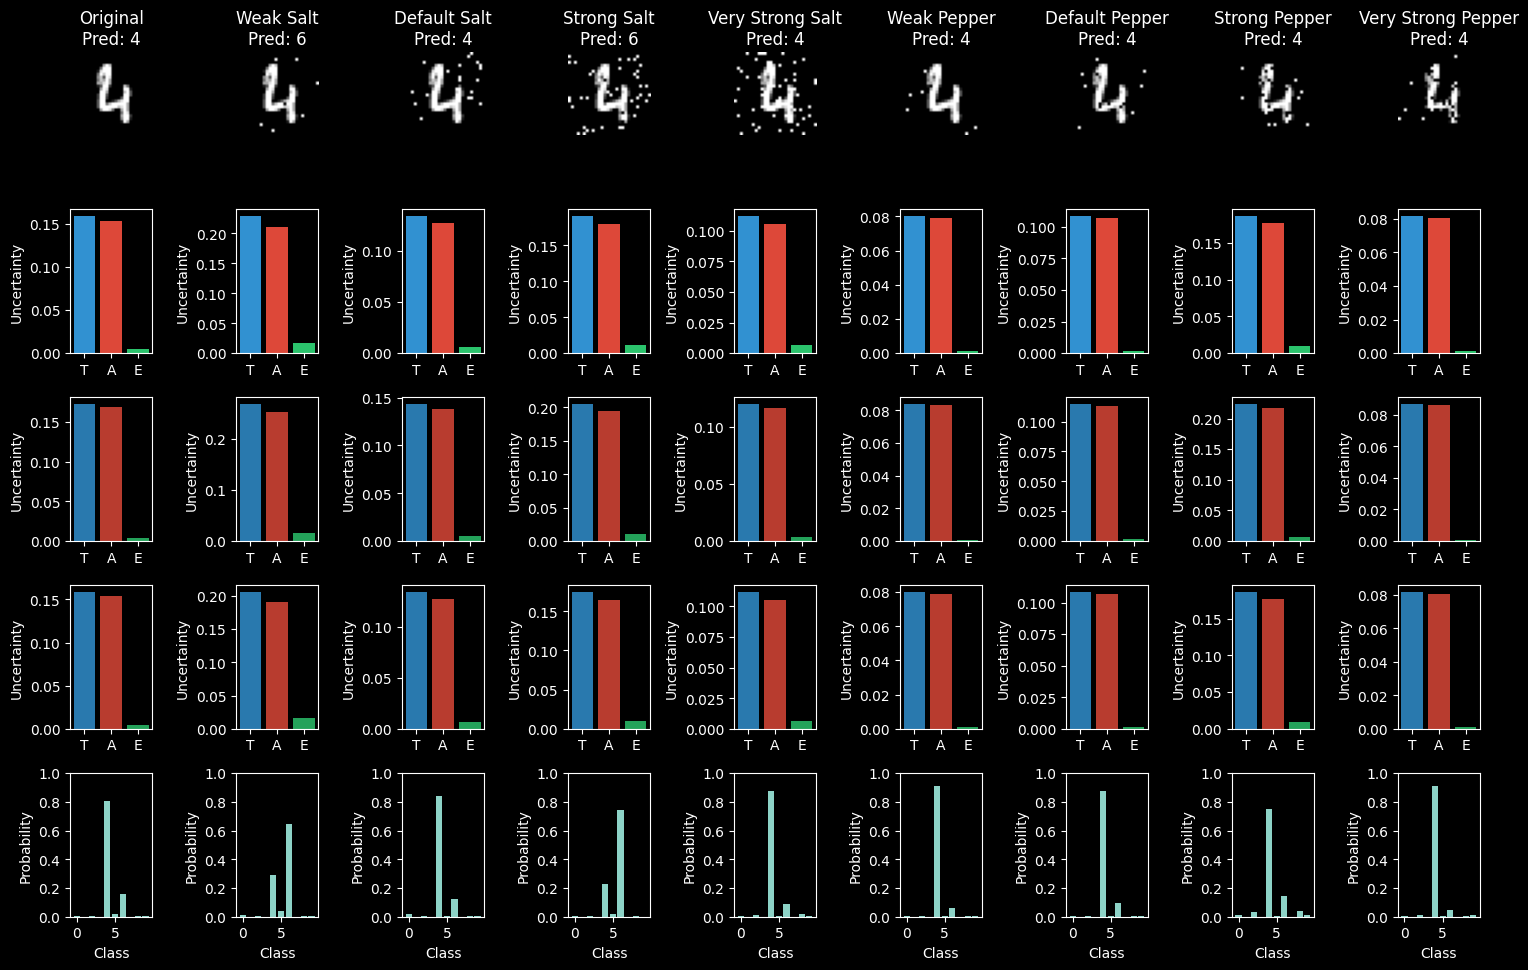

In [30]:
test_on_corruptions(lenet_model, test_loader, device, T=20, batch_idx=222, img_idx=6)


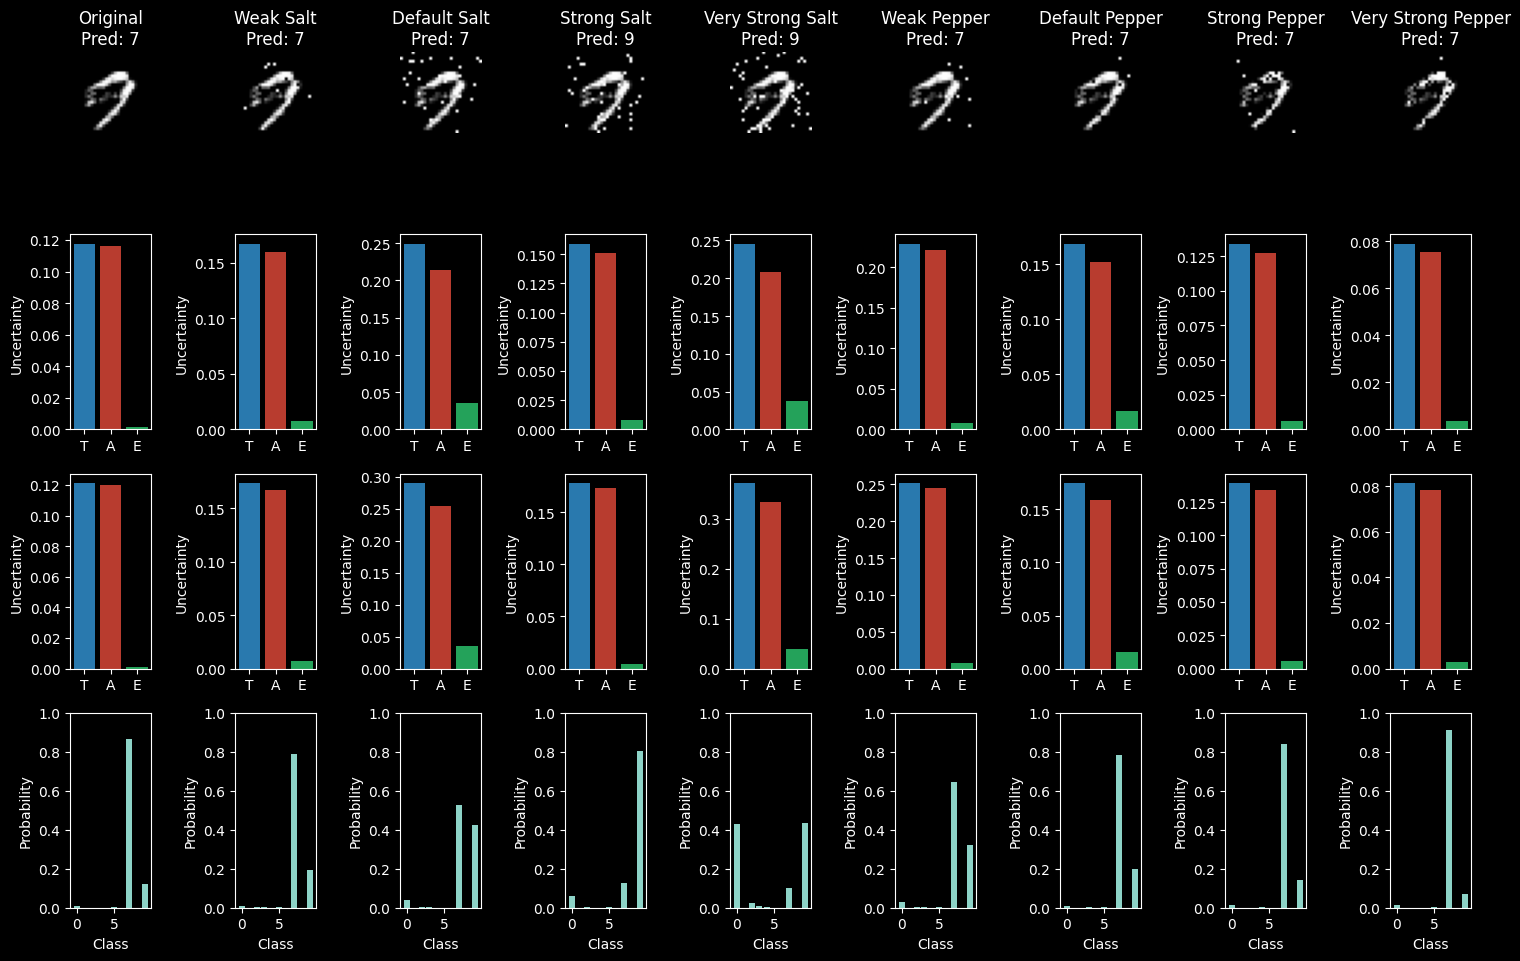

In [25]:
test_on_corruptions(lenet_model, test_loader, device, batch_idx=688, img_idx=10)


## Noise + Salt&Pepper

In [35]:
corruptions = {
    'Original': lambda x: x,
    'Gaussian Noise': lambda x: x + torch.randn_like(x) * 0.3,
    'Salt & Pepper': lambda x: add_salt_pepper(x, 0.1),
    'Combined': lambda x: add_salt_pepper(x + torch.randn_like(x) * 0.3, 0.1),
}


Logits std: 0.1071

Original - Pred: 4, Label: 4
Total uncertainty - Pred: 0.2394, Label: 0.2394
Aleatoric uncertainty - Pred: 0.1083, Label: 0.1083
Epistemic uncertainty - Pred: 0.1311, Label: 0.1311

Total uncertainty (not pred): 0.3211
Aleatoric uncertainty (not pred): 0.1592
Epistemic uncertainty (not pred): 0.1619

Logits std: 0.0195

Gaussian Noise - Pred: 4, Label: 4
Total uncertainty - Pred: 0.0588, Label: 0.0588
Aleatoric uncertainty - Pred: 0.0520, Label: 0.0520
Epistemic uncertainty - Pred: 0.0068, Label: 0.0068

Total uncertainty (not pred): 0.0601
Aleatoric uncertainty (not pred): 0.0546
Epistemic uncertainty (not pred): 0.0055

Logits std: 0.1271

Salt & Pepper - Pred: 6, Label: 4
Total uncertainty - Pred: 0.2488, Label: 0.0904
Aleatoric uncertainty - Pred: 0.0869, Label: 0.0577
Epistemic uncertainty - Pred: 0.1619, Label: 0.0326

Total uncertainty (not pred): 0.4001
Aleatoric uncertainty (not pred): 0.2423
Epistemic uncertainty (not pred): 0.1578

Logits std: 0.0906

Com

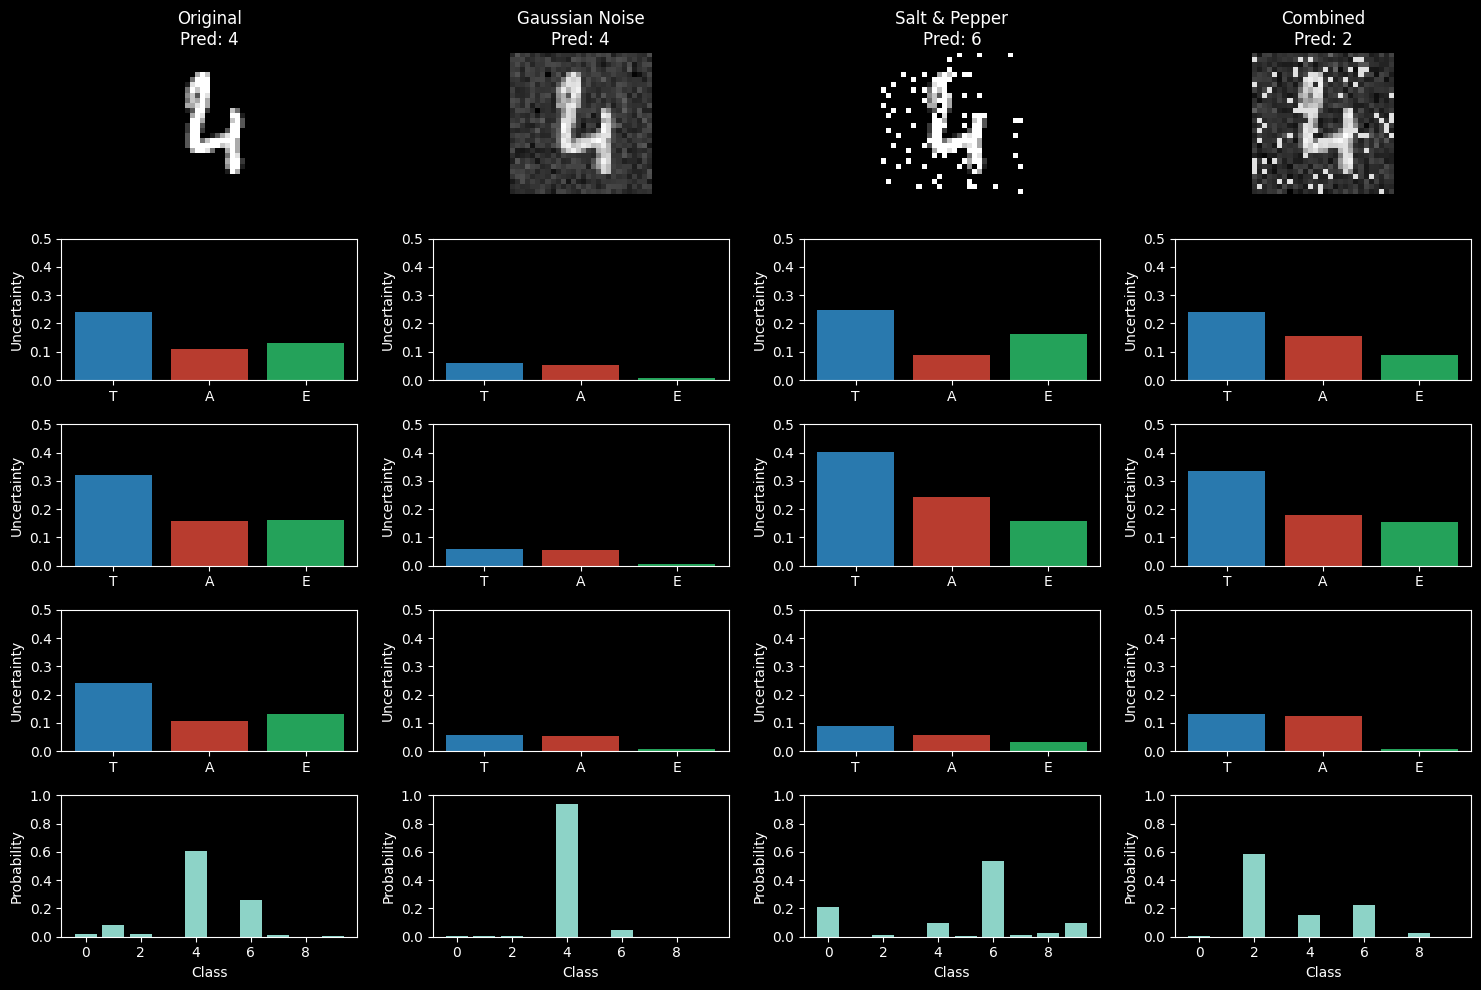

In [36]:
test_on_corruptions(lenet_model, test_loader, device, T=5, batch_idx=222, img_idx=6)

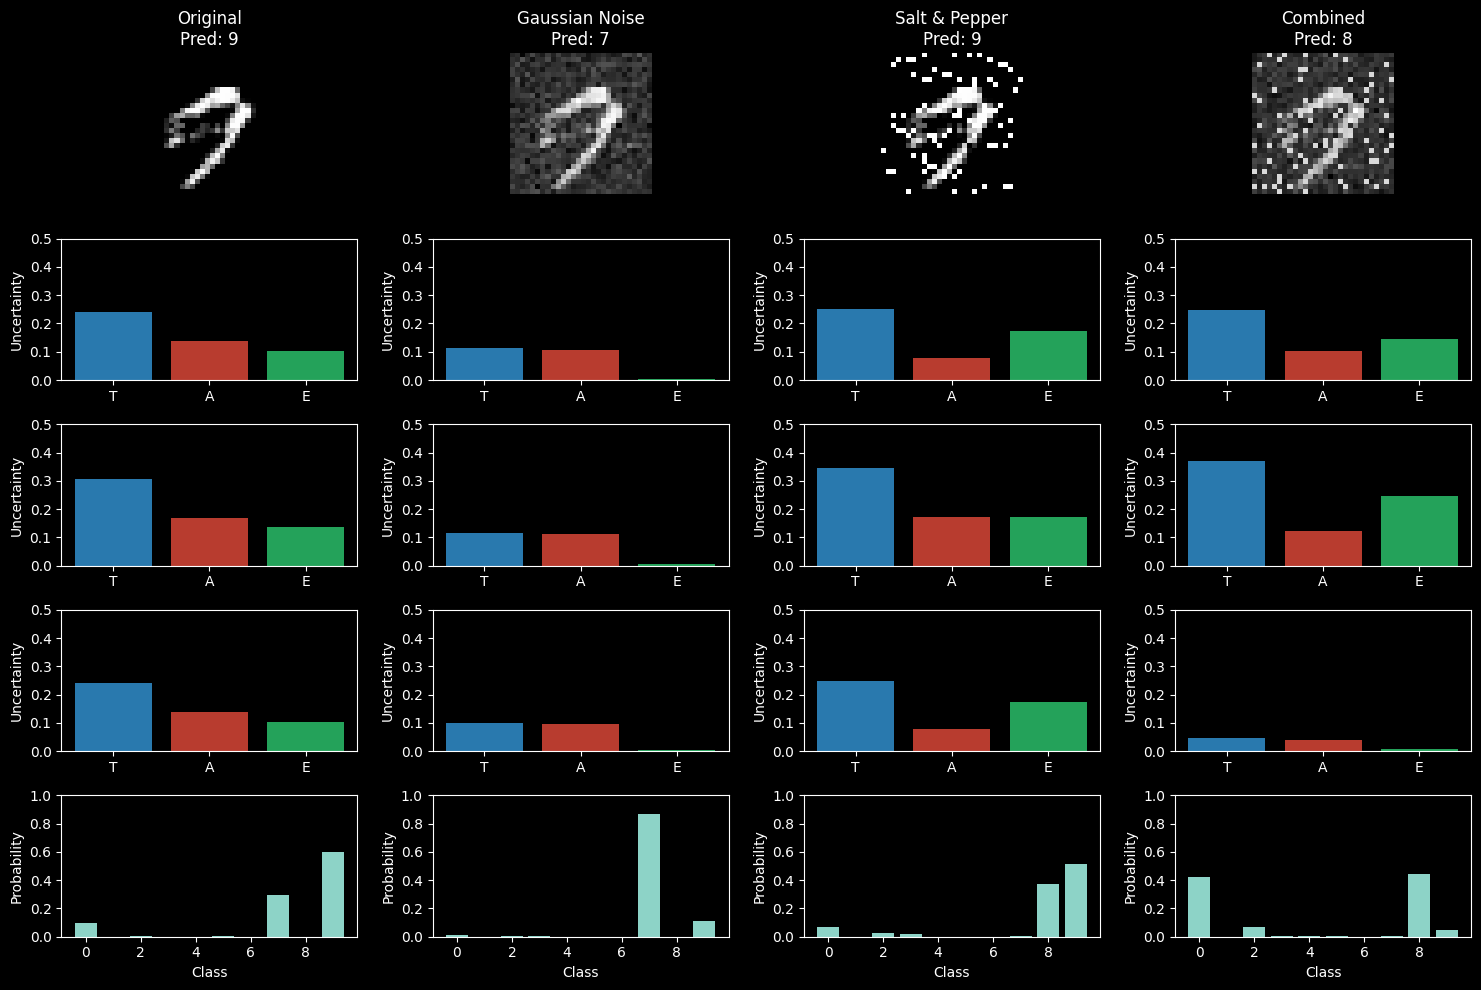

In [40]:
test_on_corruptions(lenet_model, test_loader, device, batch_idx=688, img_idx=10)

Logits std: 0.0265

Original - Pred: 3, Label: 0
Total uncertainty - Pred: 0.2352, Label: 0.0799
Aleatoric uncertainty - Pred: 0.2298, Label: 0.0792
Epistemic uncertainty - Pred: 0.0054, Label: 0.0007

Total uncertainty (not pred): 0.5321
Aleatoric uncertainty (not pred): 0.5244
Epistemic uncertainty (not pred): 0.0077

Logits std: 0.0298

Gaussian Noise - Pred: 3, Label: 0
Total uncertainty - Pred: 0.2443, Label: 0.0835
Aleatoric uncertainty - Pred: 0.2324, Label: 0.0826
Epistemic uncertainty - Pred: 0.0119, Label: 0.0009

Total uncertainty (not pred): 0.4949
Aleatoric uncertainty (not pred): 0.4864
Epistemic uncertainty (not pred): 0.0085

Logits std: 0.0222

Salt & Pepper - Pred: 3, Label: 0
Total uncertainty - Pred: 0.2497, Label: 0.0103
Aleatoric uncertainty - Pred: 0.2430, Label: 0.0103
Epistemic uncertainty - Pred: 0.0066, Label: 0.0000

Total uncertainty (not pred): 0.3791
Aleatoric uncertainty (not pred): 0.3715
Epistemic uncertainty (not pred): 0.0077

Logits std: 0.0229

Com

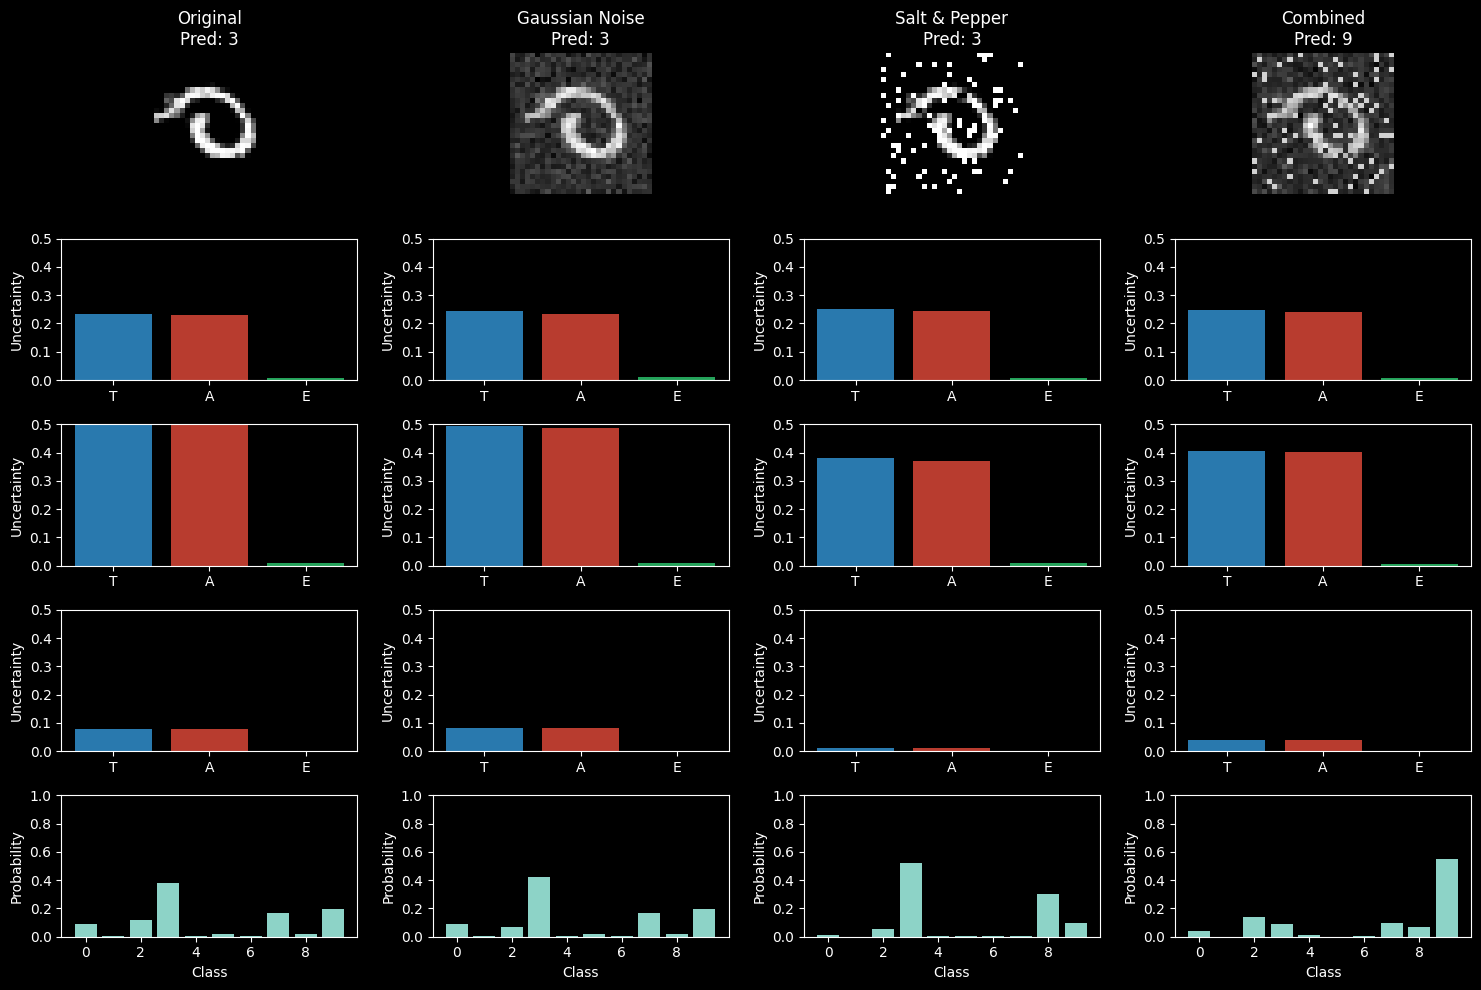

In [30]:
test_on_corruptions(lenet_model, test_loader, device, T=20, batch_idx=290, img_idx=5)